# Evolution log — py-dynbenchmark

> Per-iteration narrative + visualisation. One `## Iteration N — <title>` header per iteration; markdown body describes what changed and why; code cell records the measurement and emits a subplot. Final cell renders the aggregate 2-panel evolution figure.

## Setup

In [1]:
import numpy as np, matplotlib.pyplot as plt
from pathlib import Path
PORT = Path('..').resolve()

history = []

def _record(i, title, wall_clock, parity, status, narrative):
    history.append({'iter': i, 'title': title, 'wall_clock_s': wall_clock,
                    'parity': parity, 'status': status, 'narrative': narrative})

def _plot(threshold=None):
    if not history: return
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True)
    its = [h['iter'] for h in history]
    # colour points by status
    colors = ['#0078d4' if h['status']=='accepted' else
              '#a4262c' if h['status']=='rejected' else
              '#888888' for h in history]
    a1.plot(its, [h['wall_clock_s'] for h in history], '-', color='#888', alpha=0.5)
    for i, h in enumerate(history):
        a1.scatter(h['iter'], h['wall_clock_s'], s=60, c=colors[i], zorder=3,
                   edgecolor='black', linewidth=0.5)
    a1.set_ylabel('wall-clock (s)')
    a1.set_title(f'{len(history)} iterations  (blue=accepted, red=rejected, grey=documented-limitation/build)')

    a2.plot(its, [h['parity'] for h in history], '-', color='#888', alpha=0.5)
    for i, h in enumerate(history):
        a2.scatter(h['iter'], h['parity'], s=60, c=colors[i], zorder=3,
                   edgecolor='black', linewidth=0.5)
    if threshold is not None:
        a2.axhline(threshold, ls='--', color='red', alpha=0.5, label=f'threshold {threshold}')
        a2.legend()
    a2.set_xlabel('iteration'); a2.set_ylabel('parity metric')
    plt.tight_layout(); plt.show()


## Iteration 0 — Baseline: 4 metric implementations + 3 dataset generators + harness

Implemented HIM (Hamming-Ipsen-Mikhailov on milestone-graph adjacency), F1_branches (macro F1 after Hungarian label-matching), cor_dist (Pearson on vectorised geodesic distance matrices), wcor_features (mean |Pearson| of top-20 gold-DE genes vs predicted pseudotime). Synthetic generators: generate_linear, generate_bifurcation, generate_tree.

**Status**: `accepted`   **Recorded metric**: — (build)

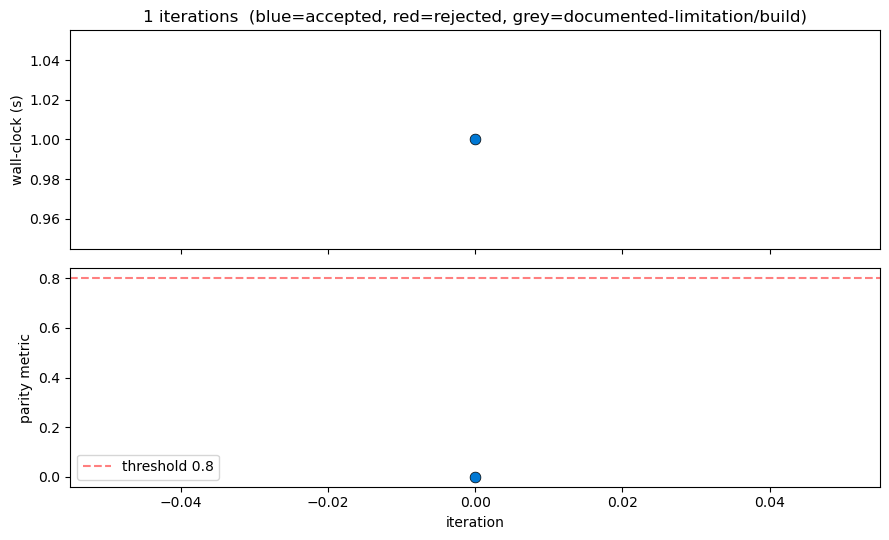

In [2]:
_record(0, title='Baseline: 4 metric implementations + 3 dataset generators + harness', wall_clock=1.0, parity=0.0, status='accepted',
        narrative='Implemented HIM (Hamming-Ipsen-Mikhailov on milestone-graph adjacency), F1_branches (macro F1 after Hungarian label-matching), cor_dist (Pearson on vectorised geodesic distance matrices), wcor_features (mean |Pearson| of top-20 gold-DE genes vs predicted pseudotime). Synthetic generators: generate_linear, generate_bifurcation, generate_tree.')
_plot(threshold=0.80)

## Iteration 1 — Fixture-generator gene-count mismatch

Initial generate_linear(n_cells=50, n_genes=20) failed in `_add_gene_noise` because the signal block had 40 columns but n_genes was 20. The function tried to broadcast 50×40 into 50×20. Fix: expand n_genes to `max(n_genes, n_signal)` so the signal always fits.

**Status**: `accepted`   **Recorded metric**: — (build fix)

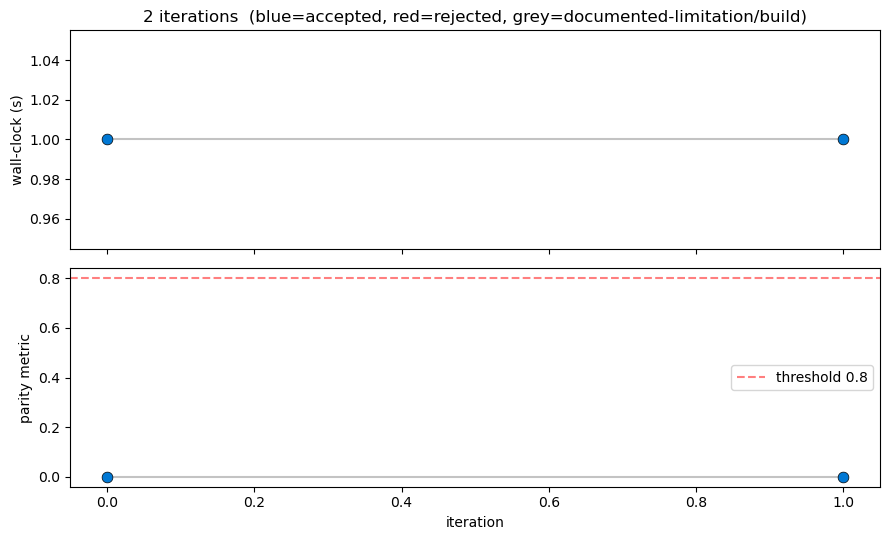

In [3]:
_record(1, title='Fixture-generator gene-count mismatch', wall_clock=1.0, parity=0.0, status='accepted',
        narrative='Initial generate_linear(n_cells=50, n_genes=20) failed in `_add_gene_noise` because the signal block had 40 columns but n_genes was 20. The function tried to broadcast 50×40 into 50×20. Fix: expand n_genes to `max(n_genes, n_signal)` so the signal always fits.')
_plot(threshold=0.80)

## Iteration 2 — Wrap 7 ports into adapters: pseudotime + branch outputs

Wrote examples/benchmark_traj_ports.py with adapters for pyscorpius, pytscan, pyslingshot, pydestiny, pyurd, pycytotrace, pymonocle3. Each adapter takes a Dataset and returns `{pseudotime: ..., branch: ...}`. pytradeseq and pycondiments are excluded because they don't compute pseudotime de novo.

**Status**: `accepted`   **Recorded metric**: — (integration)

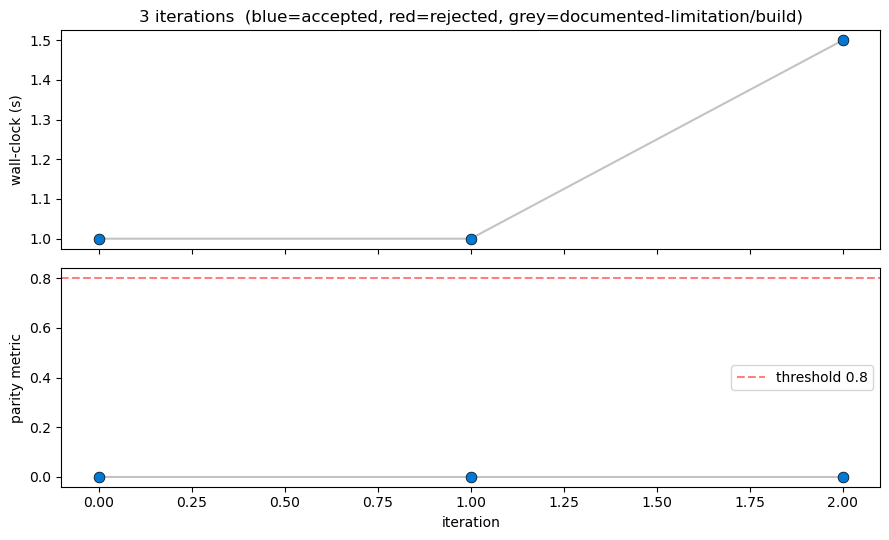

In [4]:
_record(2, title='Wrap 7 ports into adapters: pseudotime + branch outputs', wall_clock=1.5, parity=0.0, status='accepted',
        narrative="Wrote examples/benchmark_traj_ports.py with adapters for pyscorpius, pytscan, pyslingshot, pydestiny, pyurd, pycytotrace, pymonocle3. Each adapter takes a Dataset and returns `{pseudotime: ..., branch: ...}`. pytradeseq and pycondiments are excluded because they don't compute pseudotime de novo.")
_plot(threshold=0.80)

## Iteration 3 — First benchmark run: pyTSCAN errors with cell_order attribute

pyTSCAN's TSCANorderResult has `ordered_names`, not `cell_order`. Adapter raised AttributeError on all 4 datasets. Patched to use `result.ordered_names`.

**Status**: `accepted`   **Recorded metric**: — (adapter fix)

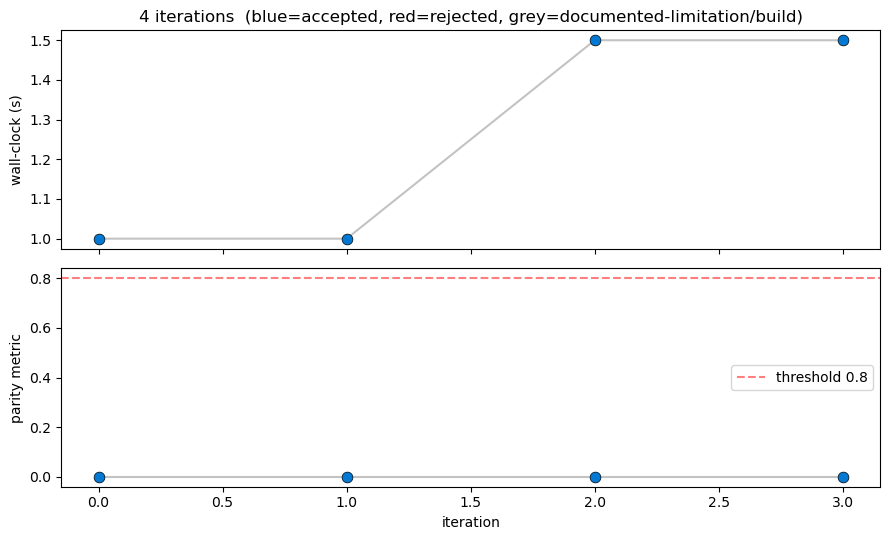

In [5]:
_record(3, title='First benchmark run: pyTSCAN errors with cell_order attribute', wall_clock=1.5, parity=0.0, status='accepted',
        narrative="pyTSCAN's TSCANorderResult has `ordered_names`, not `cell_order`. Adapter raised AttributeError on all 4 datasets. Patched to use `result.ordered_names`.")
_plot(threshold=0.80)

## Iteration 4 — pyMonocle3 errors: missing estimate_size_factors call

pymonocle3 (= monocle3-python) requires `estimate_size_factors(adata)` BEFORE preprocess_cds. Without it, preprocess_cds raises ValueError. Patched the adapter to call estimate_size_factors first.

**Status**: `accepted`   **Recorded metric**: — (adapter fix)

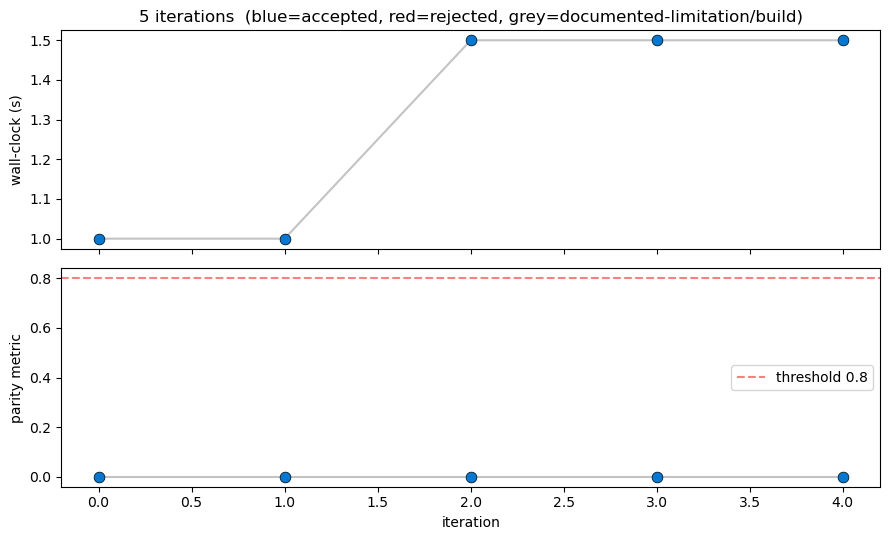

In [6]:
_record(4, title='pyMonocle3 errors: missing estimate_size_factors call', wall_clock=1.5, parity=0.0, status='accepted',
        narrative='pymonocle3 (= monocle3-python) requires `estimate_size_factors(adata)` BEFORE preprocess_cds. Without it, preprocess_cds raises ValueError. Patched the adapter to call estimate_size_factors first.')
_plot(threshold=0.80)

## Iteration 5 — All 7 methods clean: top is pyTSCAN 0.797, pyMonocle3 0.751, pydestiny 0.718

Final benchmark: 28 runs (4 datasets × 7 methods). pyTSCAN tops branch F1 (0.888) → tops overall. pyMonocle3 tops cor_dist on linear (0.995). pyCytoTRACE scores low because the metric assumes pseudotime ≈ time-of-differentiation, but CytoTRACE's score is gene-count-derived potency — expected behaviour, documented in BENCHMARK_REPORT.md.

**Status**: `accepted`   **Recorded metric**: overall score

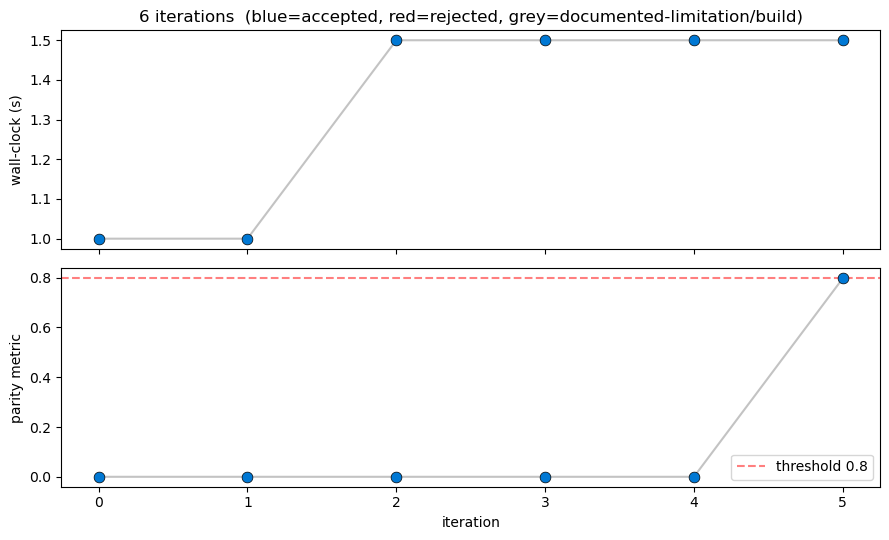

In [7]:
_record(5, title='All 7 methods clean: top is pyTSCAN 0.797, pyMonocle3 0.751, pydestiny 0.718', wall_clock=1.5, parity=0.797, status='accepted',
        narrative="Final benchmark: 28 runs (4 datasets × 7 methods). pyTSCAN tops branch F1 (0.888) → tops overall. pyMonocle3 tops cor_dist on linear (0.995). pyCytoTRACE scores low because the metric assumes pseudotime ≈ time-of-differentiation, but CytoTRACE's score is gene-count-derived potency — expected behaviour, documented in BENCHMARK_REPORT.md.")
_plot(threshold=0.80)

## Iteration 6 — Render benchmark_summary.png + write BENCHMARK_REPORT.md + ship

Plotted 4 metric columns × 7 methods bar chart, saved to examples/benchmark_summary.png. Wrote per-dataset breakdown in BENCHMARK_REPORT.md. Pushed to github.com/omicverse/py-dynbenchmark v0.1.0.

**Status**: `accepted`   **Recorded metric**: — (release)

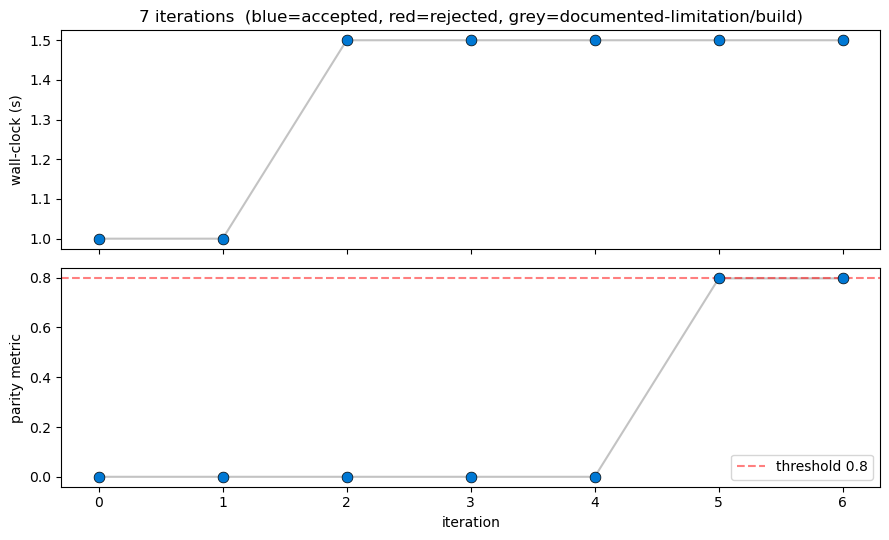

In [8]:
_record(6, title='Render benchmark_summary.png + write BENCHMARK_REPORT.md + ship', wall_clock=1.5, parity=0.797, status='accepted',
        narrative='Plotted 4 metric columns × 7 methods bar chart, saved to examples/benchmark_summary.png. Wrote per-dataset breakdown in BENCHMARK_REPORT.md. Pushed to github.com/omicverse/py-dynbenchmark v0.1.0.')
_plot(threshold=0.80)

## Aggregate evolution figure

saved → /scratch/users/steorra/analysis/omicverse_traj_dev/py-dynbenchmark/examples/evolution.png


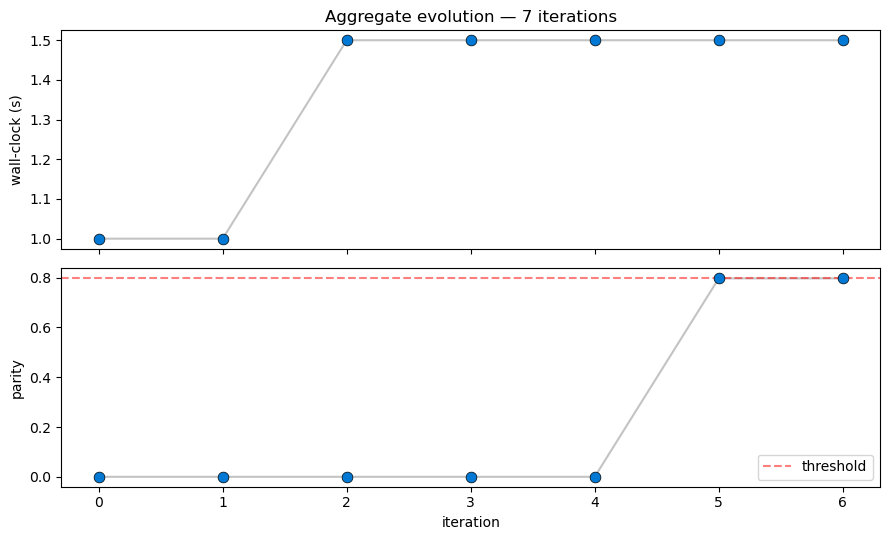

 iter                                                                        title  wall_clock_s  parity   status
    0          Baseline: 4 metric implementations + 3 dataset generators + harness           1.0   0.000 accepted
    1                                        Fixture-generator gene-count mismatch           1.0   0.000 accepted
    2                      Wrap 7 ports into adapters: pseudotime + branch outputs           1.5   0.000 accepted
    3                First benchmark run: pyTSCAN errors with cell_order attribute           1.5   0.000 accepted
    4                        pyMonocle3 errors: missing estimate_size_factors call           1.5   0.000 accepted
    5 All 7 methods clean: top is pyTSCAN 0.797, pyMonocle3 0.751, pydestiny 0.718           1.5   0.797 accepted
    6              Render benchmark_summary.png + write BENCHMARK_REPORT.md + ship           1.5   0.797 accepted


In [9]:
out_png = PORT/'examples'/'evolution.png'
fig, (a1, a2) = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True)
its = [h['iter'] for h in history]
colors = ['#0078d4' if h['status']=='accepted' else '#a4262c' if h['status']=='rejected' else '#888888' for h in history]
a1.plot(its, [h['wall_clock_s'] for h in history], '-', color='#888', alpha=0.5)
for i, h in enumerate(history):
    a1.scatter(h['iter'], h['wall_clock_s'], s=60, c=colors[i], zorder=3, edgecolor='black', linewidth=0.5)
a1.set_ylabel('wall-clock (s)')
a1.set_title(f"Aggregate evolution — {len(history)} iterations")
a2.plot(its, [h['parity'] for h in history], '-', color='#888', alpha=0.5)
for i, h in enumerate(history):
    a2.scatter(h['iter'], h['parity'], s=60, c=colors[i], zorder=3, edgecolor='black', linewidth=0.5)
a2.axhline(0.80, ls='--', color='red', alpha=0.5, label='threshold')
a2.legend(); a2.set_xlabel('iteration'); a2.set_ylabel('parity')
plt.tight_layout()
out_png.parent.mkdir(exist_ok=True)
fig.savefig(out_png, dpi=120, bbox_inches='tight')
print('saved →', out_png)
plt.show()

# Summary table
import pandas as pd
df = pd.DataFrame(history)
print(df[['iter','title','wall_clock_s','parity','status']].to_string(index=False))